# A MODEL MUST NOT HAVE MISSING VALUES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt #.pyplot for colors in the graphs
import seaborn as sns
from sklearn.linear_model import LinearRegression #(Linear regression library is owned by scikit learn (sklearn))
from sklearn.model_selection import train_test_split

Train Test split: when building a ML model, we want to know how well it will perform on new darta not just the data it was trained on used to train the model and evaluate the performance of the model we split our data set into
two parts training set: used to teach the model. The model learns patterns, relationships and rules from this part
and test set: used to evaluate the model's performance on unseen data

In [ ]:
df_mul = pd.read_csv("/content/drive/MyDrive/archive/housing.csv")

In [ ]:
df_mul.head() #df.mul is short form of multiple linear regression variable

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df_mul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df_mul.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


NUMERICAL MISSING VALUES YOU CAN FILL THEM IN WITH MEDIAN, MEAN, AND MODE

*   FOR CATEGORICAL COLUMNS, WE WILL FIL THE MISSING VALUES WITH THE MOST FREQUENT WORD/DATA ENTRY IN THAT COLUMN
*   



In [ ]:
print("Missing values per column:")
print(df_mul.isnull().sum()) #summing the number of null values in each column

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


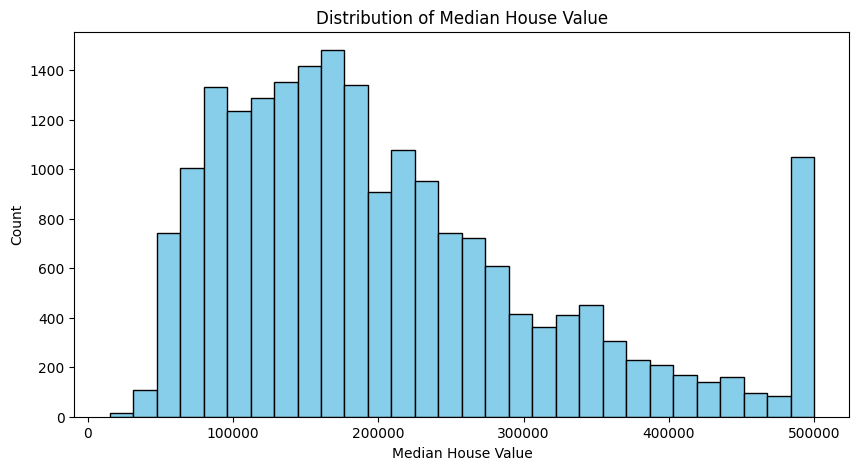

In [ ]:
# histogram for median house value
plt.figure(figsize = (10,5))
plt.hist(df_mul['median_house_value'], bins =30, color = 'skyblue', edgecolor = 'black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

In [ ]:
df_mul["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


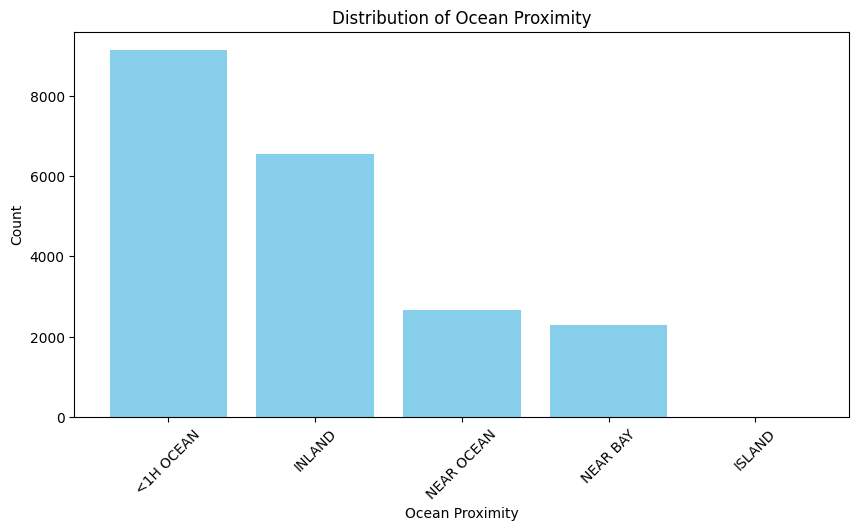

In [ ]:
plt.figure(figsize=(10,5))
ocean_counts = df_mul['ocean_proximity'].value_counts() # we basically put the count of ocean poximity
#in the variable name 'ocean_counts'
plt.bar(ocean_counts.index, ocean_counts.values, color = 'skyblue') #.index, we want the bar chart to start
# from the ocean proximity with the highest count
plt.title('Distribution of Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

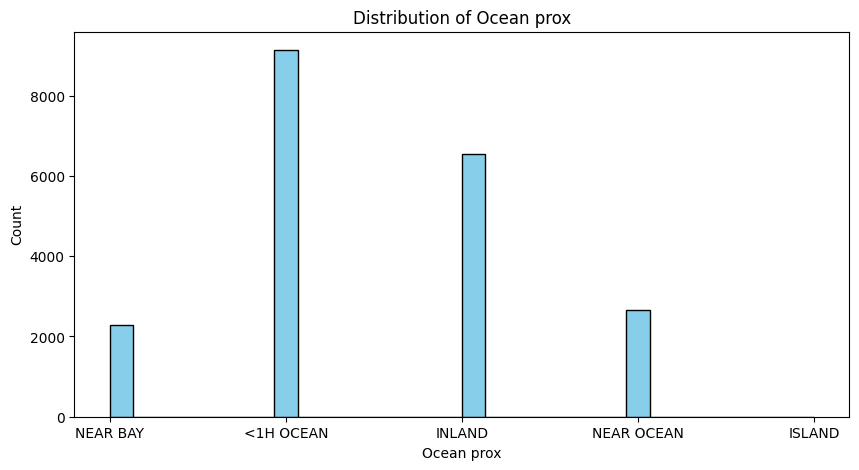

In [ ]:
plt.figure(figsize = (10,5))
plt.hist(df_mul['ocean_proximity'], bins =30, color = 'skyblue', edgecolor = 'black')
plt.title('Distribution of Ocean prox')
plt.xlabel('Ocean prox')
plt.ylabel('Count')
plt.show()

In [ ]:
df_mul = df_mul.dropna() #drop all null values

In [ ]:
#Features(multiple predictors)
X = df_mul[['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 'population',
'households','median_income']] #we dropped ocean_proximity because the ocean_proximity column is a string while
#these columns used are numerical columns

#target variable
y=df_mul['median_house_value']

We dropped ocean_proimity because the ocean_proximity column is a string while these columns used are numerical columns
The sci kit-learn  only works with numerical values, not text. It cannot calculate slope for strings.

To use ocena_proximity in themodel, we would need to convert it to numbers using techniques like

*   One-hot encoding (crreating separate columns for each category
*   Label Encoding (assigning numbers to categories



In [ ]:
model = LinearRegression()
model.fit(X,y) #training the dataset, telling the dataset to do its computation

LinearRegression()

In [ ]:
#Coefficient for each feature(slope)
coefficients = pd.DataFrame({'Feature': X.columns,
                            'Coefficient': model.coef_})
#.columns gives column names of features used to train the model
#model.coef = slope. Here it is slope assigned to each feature by the linear regression model

#Intercept
intercept = model.intercept_

display(coefficients) #we use display to print the oefficient table with grid whie you can use print
#but it will print the coefficient table clustered
print(f"Intercept: {intercept}") #since this is not a table just one variable we will be using print

,Feature,Coefficient
0,longitude,-42730.120454
1,latitude,-42509.736942
2,housing_median_age,1157.900307
3,total_rooms,-8.249725
4,total_bedrooms,113.820707
5,population,-38.385578
6,households,47.701351
7,median_income,40297.521715


Intercept: -3585395.7478930587


y = Bx + B1X1 + B2X2+....+ B3X3
prediction = (Coefficient 1 x Feature 1) + (Coefficient 2 x Feature ) + ... + Intercept

Where B is a coefficient/slope and X is a feature

In [ ]:
y_pred = model.predict(X) #predict y using X
print(y_pred)

[411270.20746023 415943.95527539 380534.16332108 ...  24989.18869283
  37961.51486098  55555.76850636]


In [ ]:
results_df = pd.DataFrame({
    'Actual': y,
    'Predicted': y_pred})

display(results_df.head(10)) #display table with grid for the first 10 predictions

,Actual,Predicted
0,452600.0,411270.207460
1,358500.0,415943.955275
2,352100.0,380534.163321
3,341300.0,322246.854897
4,342200.0,253685.372006
5,269700.0,262267.216292
6,299200.0,254726.454291
7,241400.0,254770.455091
8,226700.0,199389.129562
9,261100.0,264465.758769


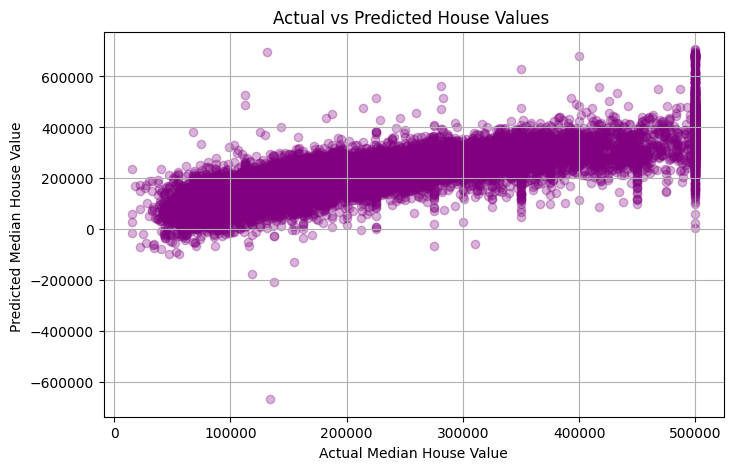

In [ ]:
# scatter plot shows the relationship of two variables
plt.figure(figsize =(8,5))
plt.scatter(y, y_pred, alpha = 0.3, color = 'purple')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value ")
plt.title("Actual vs Predicted House Values ")
plt.grid(True)
plt.show()

In [ ]:
#features (multiple predictors) hiding 20% of your data from the model

X = df_mul[['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 'population',
'households','median_income']]

#target variable
y = df_mul['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 ) # X is now = X_train and y is now = y_train
# anytime you run this model, nothing about the splitting should change regardless of the number of times you run the notebook. You can use 42 all the time
#sets the random seed to 42, This ensures you get the same split everytime you run the code, making you result reproducible. Without this you'd get differemt
#random splits each time

The training set usually takes 70% to 80% of the data wile the testing set takes 20% to 30% of the data.


X_train and y_train : 80% of the data- used to train the model


X_test and y_test: 20% of the data- used to test the model


test_size = 0.2: Allocates 20% of data for testing, leaving 80% for training




In [ ]:
X_train.head() # because we called for random_state = 42, the index is at random and it i no longer 0, 1, 2, 3, 4, the index here is at random. so now
#.head() will give you 5 different rows at random

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
17727,-121.80,37.32,14.0,4412.0,924.0,2698.0,891.0,4.7027
2057,-119.63,36.64,33.0,1036.0,181.0,620.0,174.0,3.4107
6453,-118.06,34.12,25.0,3891.0,848.0,1848.0,759.0,3.6639
4619,-118.31,34.07,28.0,2362.0,949.0,2759.0,894.0,2.2364
15266,-117.27,33.04,27.0,1839.0,392.0,1302.0,404.0,3.5500


In [ ]:
print(f"Training set size: {X_train.shape}")
print(f"test set size: {X_test.shape}")


Training set size: (16346, 8)
test set size: (4087, 8)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train) #working with the training data
#.fit is the backend computation how the model calculates for prediction

LinearRegression()

In [ ]:
#Coefficiet for each feature(slope)

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

#Intercept
intercept = model.intercept_
display(coefficients)
print(f"Intercept: {intercept}")

,Feature,Coefficient
0,longitude,-42546.706006
1,latitude,-42336.042987
2,housing_median_age,1155.097108
3,total_rooms,-8.440418
4,total_bedrooms,115.830375
5,population,-36.758767
6,households,41.640434
7,median_income,40293.278408


Intercept: -3569674.5266952454


In [ ]:
y_train_pred = model.predict(X_train)
print(y_train_pred)

[245906.31381088 141217.81122485 214449.14583332 ... 211607.39708827
 251771.91227101 257502.07643588]


In [ ]:
results_df = pd.DataFrame({
    'Actual':y_train,
    'Predicted': y_train_pred
})
display(results_df.head())

,Actual,Predicted
17727,227600.0,245906.313811
2057,110400.0,141217.811225
6453,248100.0,214449.145833
4619,305600.0,169887.750297
15266,214600.0,194069.984620


In [ ]:
y_test_pred = model.predict(X_test)
print(y_test_pred)

[197058.03752153 157508.79088918 202099.26270386 ... 131098.67538845
 155468.78077784 166363.59962367]


In [ ]:
results_df = pd.DataFrame({
    'Actual':y_test,
    'Predicted': y_test_pred
})
display(results_df.head())

,Actual,Predicted
14416,245800.0,197058.037522
16383,137900.0,157508.790889
7731,218200.0,202099.262704
1410,220800.0,173501.822738
1335,170500.0,213795.184175


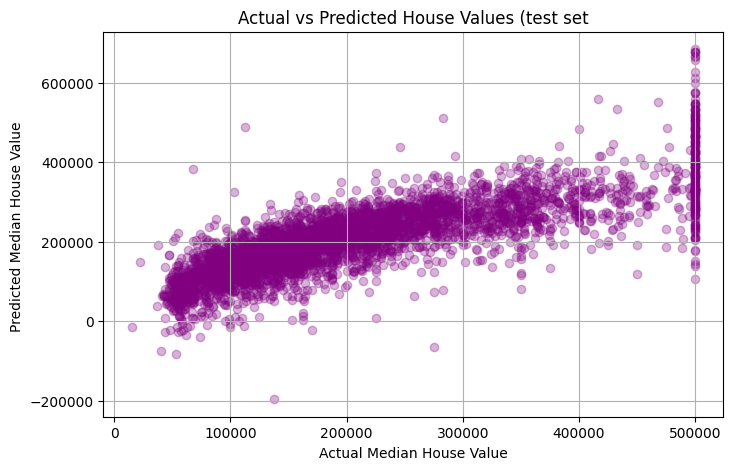

In [ ]:
plt.figure(figsize =(8,5))
plt.scatter(y_test, y_test_pred, alpha = 0.3, color = 'purple')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value ")
plt.title("Actual vs Predicted House Values (test set")
plt.grid(True)
plt.show()

#Evaluation Metric

Quantitative measures used to access the performance of a ML model. They help you understand how well your model is doing and guide you in
comaparing different models or turning them for better results.
Mean absolute error (MAE): measures the average size of errors in your prediction wwithout considering direction (it treats over prediction and
under prediction equally). #The lower your MAE the better your model.

MAE is basically The distance btwn the regression line and the datapoint. On average how far my predictions are from the actual values. The sum of the difference between the the actual values and the predicted values.
$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

R2(r squared): tells you how well your regression model fits the data. It answers the question "How much of the variation in the target (Y) can be explained by the model ?"

R2 rages from -1 to 1
Imagine you are predictiong exam scores based on study hours.


If R2 = 0.9 then your model explains 90% of the reason why students got their score


If r2 = 0.2 then your model expalins 20% of it. The rest is random noise or missing features

r2 = 1 - perfect model (100% of the variation is expained)


r2 = 0 - useless model (explains nothing; same as guessng the mean )


r2 < 0 - very bad (worse than just using the average value)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# caalculate metrics
mae = mean_absolute_error(y_test, y_test_pred) #using the test set because the model knows nothing about this test set, evalutaing the data based on this test set

#round results
mae = round(mae, 2 )

#print results
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 51372.67


In [ ]:
r2 = r2_score(y_test, y_pred_test) # we are evaluating on the test model
r2 = round(r2,2)

print(f"R-squared(R2): {r2}") # 60% (based on the result) of our features determines are predictions

R-squared(R2): 0.64
